In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path



In [2]:
DATA_PATH = Path("../data/raw/sparkov/fraudTrain.csv")

df = pd.read_csv(DATA_PATH)

# Remove original CSV index
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Convert timestamp
df["transaction_time"] = pd.to_datetime(df["trans_date_trans_time"])

print("Shape:", df.shape)

Shape: (1296675, 23)


In [3]:
df["hour"] = df["transaction_time"].dt.hour
df["day_of_week"] = df["transaction_time"].dt.dayofweek
df["month"] = df["transaction_time"].dt.month
df["date"] = df["transaction_time"].dt.date

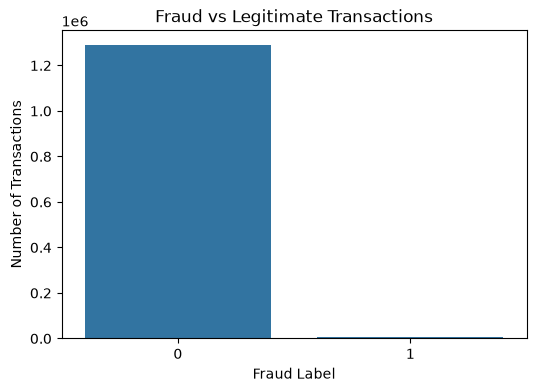

In [4]:
fraud_counts = df["is_fraud"].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(
    x=fraud_counts.index.astype(str),
    y=fraud_counts.values
)

plt.xlabel("Fraud Label")
plt.ylabel("Number of Transactions")
plt.title("Fraud vs Legitimate Transactions")
plt.show()

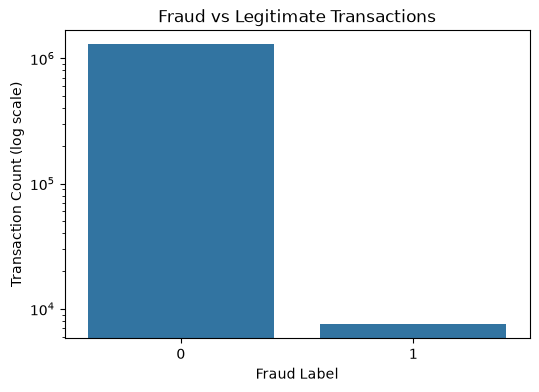

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="is_fraud")

plt.yscale("log")
plt.xlabel("Fraud Label")
plt.ylabel("Transaction Count (log scale)")
plt.title("Fraud vs Legitimate Transactions")
plt.show()

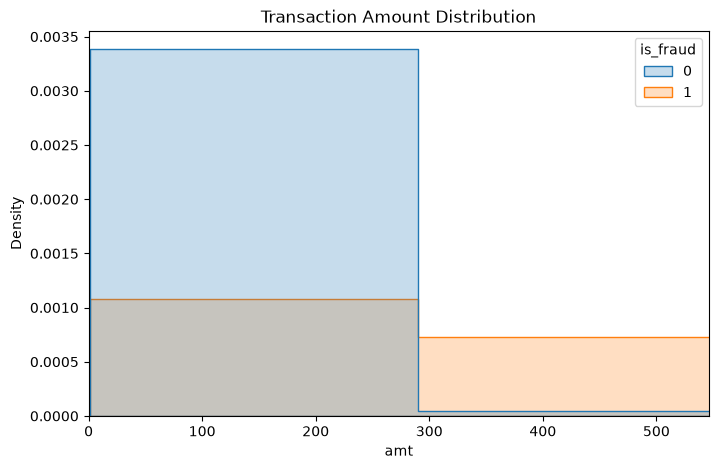

In [6]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="amt",
    hue="is_fraud",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)

plt.xlim(0, df["amt"].quantile(0.99))
plt.title("Transaction Amount Distribution")
plt.show()

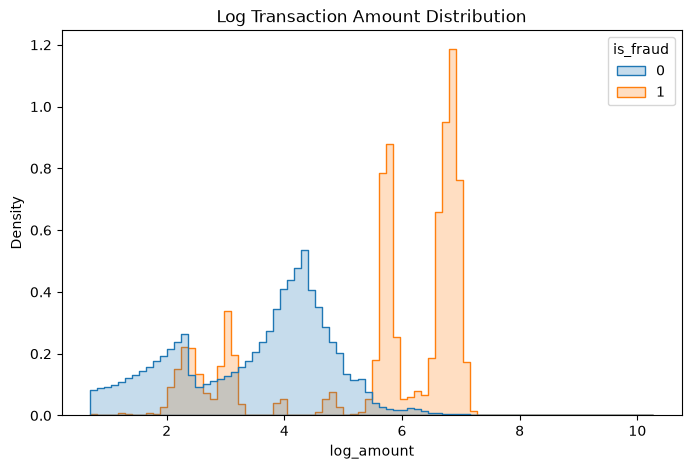

In [7]:
df["log_amount"] = np.log1p(df["amt"])

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="log_amount",
    hue="is_fraud",
    bins=80,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Log Transaction Amount Distribution")
plt.show()

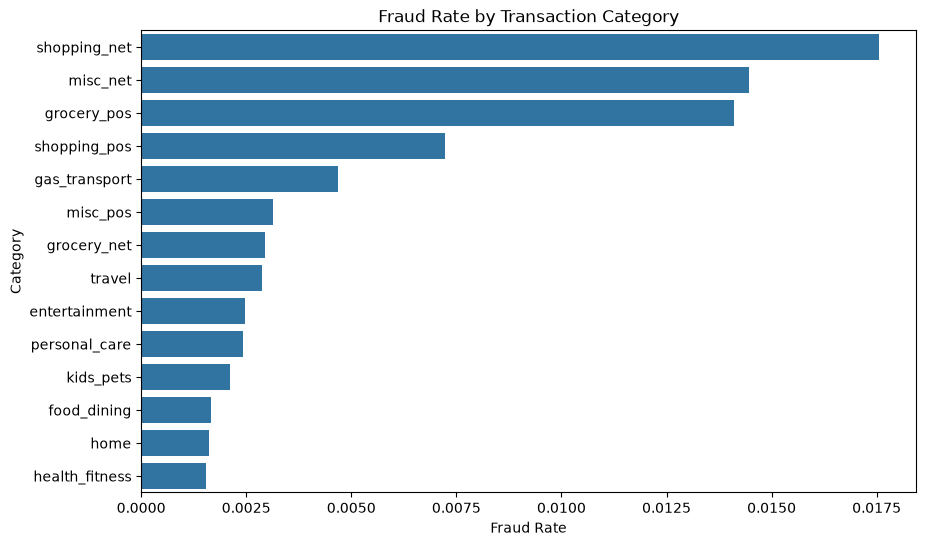

In [8]:
category_fraud = (
    df.groupby("category")["is_fraud"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_fraud,
    x="is_fraud",
    y="category"
)

plt.xlabel("Fraud Rate")
plt.ylabel("Category")
plt.title("Fraud Rate by Transaction Category")
plt.show()

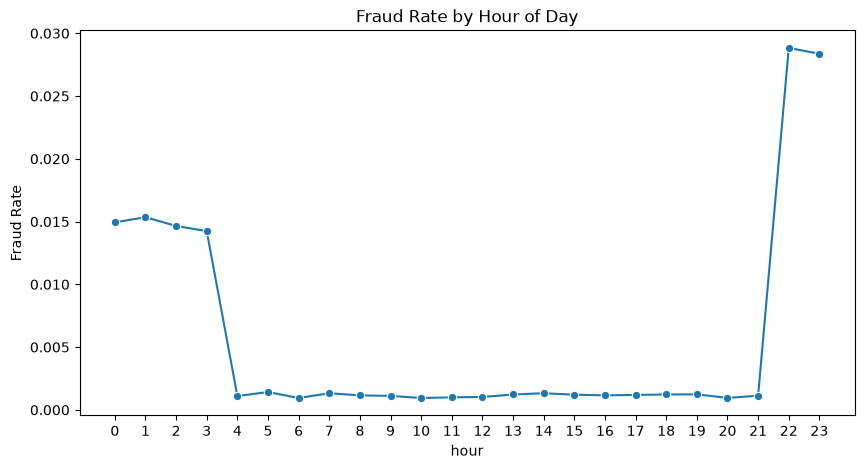

In [9]:
hourly_fraud = (
    df.groupby("hour")["is_fraud"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hourly_fraud,
    x="hour",
    y="is_fraud",
    marker="o"
)

plt.xticks(range(24))
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Hour of Day")
plt.show()

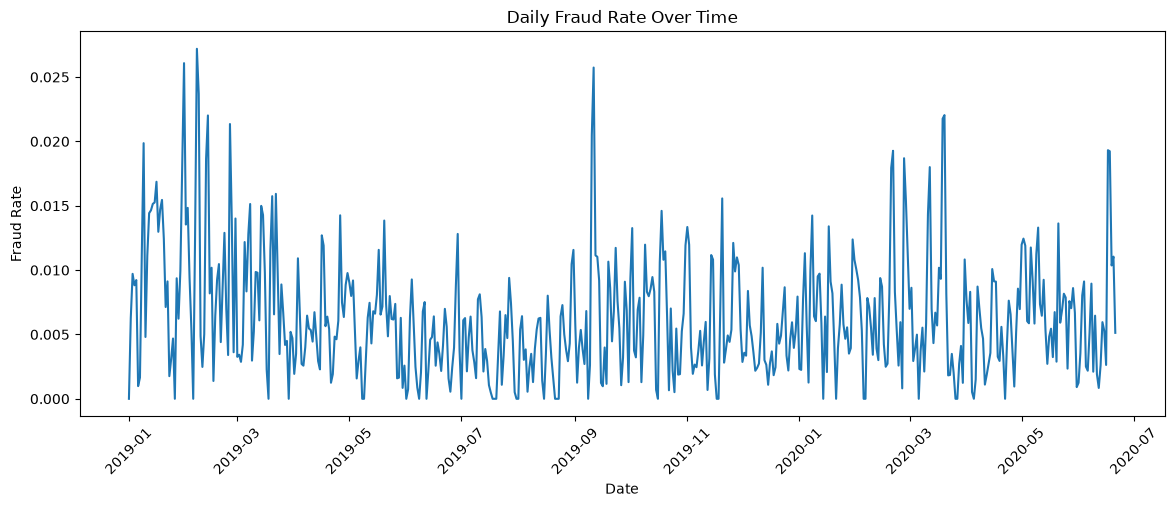

In [10]:
daily_fraud = (
    df.groupby("date")["is_fraud"]
      .agg(
          transactions="count",
          fraud_count="sum"
      )
)

daily_fraud["fraud_rate"] = (
    daily_fraud["fraud_count"] /
    daily_fraud["transactions"]
)

plt.figure(figsize=(14, 5))

sns.lineplot(
    x=daily_fraud.index,
    y=daily_fraud["fraud_rate"]
)

plt.xlabel("Date")
plt.ylabel("Fraud Rate")
plt.title("Daily Fraud Rate Over Time")
plt.xticks(rotation=45)
plt.show()

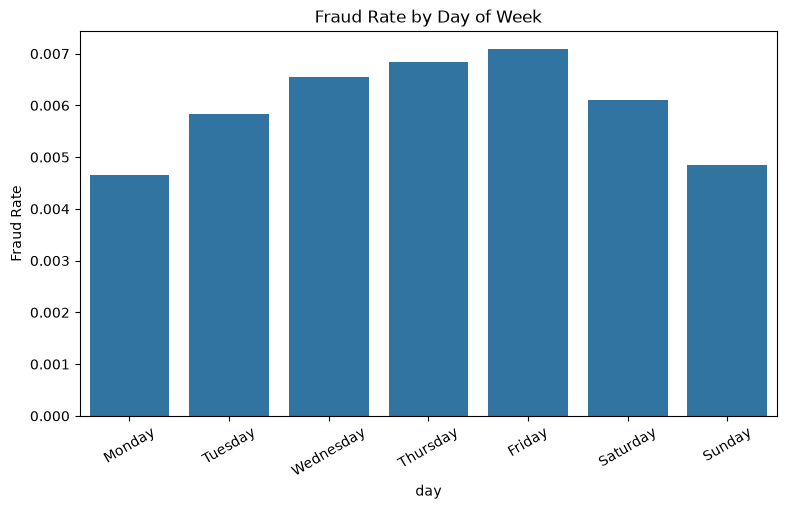

In [11]:
weekday_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

weekday_fraud = (
    df.groupby("day_of_week")["is_fraud"]
      .mean()
      .reset_index()
)

weekday_fraud["day"] = weekday_fraud["day_of_week"].map(weekday_names)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=weekday_fraud,
    x="day",
    y="is_fraud"
)

plt.xticks(rotation=30)
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Day of Week")
plt.show()

In [12]:
customer_stats = (
    df.groupby("cc_num")
      .agg(
          transaction_count=("trans_num", "count"),
          avg_amount=("amt", "mean"),
          median_amount=("amt", "median"),
          std_amount=("amt", "std"),
          fraud_count=("is_fraud", "sum")
    )
)

customer_stats.head()

,transaction_count,avg_amount,median_amount,std_amount,fraud_count
cc_num,,,,,
60416207185,1518,56.023366,36.640,122.632635,9
60422928733,1531,69.000784,52.460,102.681962,12
60423098130,510,115.046333,35.300,1202.988005,10
60427851591,528,111.987898,76.705,143.310653,14
60487002085,496,50.726028,35.640,65.843969,0


In [13]:
customer_stats = (
    df.groupby("cc_num")
      .agg(
          transaction_count=("trans_num", "count"),
          avg_amount=("amt", "mean"),
          median_amount=("amt", "median"),
          std_amount=("amt", "std"),
          fraud_count=("is_fraud", "sum")
    )
)

customer_stats.head()

,transaction_count,avg_amount,median_amount,std_amount,fraud_count
cc_num,,,,,
60416207185,1518,56.023366,36.640,122.632635,9
60422928733,1531,69.000784,52.460,102.681962,12
60423098130,510,115.046333,35.300,1202.988005,10
60427851591,528,111.987898,76.705,143.310653,14
60487002085,496,50.726028,35.640,65.843969,0


In [14]:
customer_avg = df.groupby("cc_num")["amt"].transform("mean")

df["amount_deviation_ratio"] = (
    df["amt"] / customer_avg
)

In [15]:
df.groupby("is_fraud")["amount_deviation_ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,0.965578,2.216796,0.008779,0.153625,0.666258,1.178807,386.481588
1,7506.0,6.912082,5.883882,0.008693,1.029515,5.184560,12.379291,23.912014


In [16]:
from math import radians, sin, cos, sqrt, atan2

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

In [17]:
df["customer_merchant_distance_km"] = haversine_distance(
    df["lat"],
    df["long"],
    df["merch_lat"],
    df["merch_long"]
)

In [18]:
df.groupby("is_fraud")["customer_merchant_distance_km"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,76.113756,29.119051,0.022255,55.332701,78.233012,98.504498,152.117173
1,7506.0,76.268330,28.752602,0.738769,55.632890,77.931954,98.391090,144.522410


# Initial EDA Findings

1. Fraud represents a very small fraction of transactions, creating a
   highly imbalanced classification problem.

2. Fraudulent transactions have substantially different transaction
   amount distributions from legitimate transactions.

3. Fraud rates vary across transaction categories.

4. Transaction time may provide useful behavioural information.

5. The dataset contains substantial per-customer transaction history,
   making customer-level behavioural modelling feasible.

6. Customer-to-merchant geographic distance is available and may provide
   an additional behavioural signal.

7. Future feature engineering must avoid temporal data leakage.